# Trend Strategy Research Notebook

## Research Objective

This notebook evaluates a systematic long-only crypto trend strategy built on 4-hour bar data across a fixed liquid universe. The goal is to assess whether the strategy exhibits sufficient robustness, risk-adjusted return, and implementation simplicity to justify live deployment in the Roostoo trading competition environment.

The research focuses on five questions:

1. Does the strategy produce positive absolute and risk-adjusted returns over the full evaluation window?
2. Does performance remain acceptable after realistic transaction-cost assumptions?
3. Does the strategy retain positive behaviour in an explicit out-of-sample test segment?
4. Are drawdowns and turnover consistent with a competition setting where capital preservation and operational reliability matter?
5. Is the resulting rule set simple enough to translate cleanly into a deterministic live trading bot?

## Strategy Under Study

The strategy is a 4-hour breakout / trend-following model with:

- a rolling breakout trigger,
- medium-term trend confirmation,
- a fixed maximum holding window,
- a trailing stop discipline,
- staged position entry via tranche sizing, and
- an optional BTC market-regime filter.

## Research Design

The notebook reconstructs the strategy as an auditable backtest, runs a constrained parameter search on the training segment, selects a single deployable configuration, and then evaluates the chosen specification on full-sample, training, and out-of-sample windows under multiple transaction-cost assumptions.

The objective is not to maximize in-sample fit, but to identify a specification that is simple, explainable, and sufficiently robust for live automated trading.

In [22]:
import itertools
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
sns.set_theme(style="whitegrid")


In [23]:
AS_OF_TS = pd.Timestamp.now("UTC").floor("4h")
LOOKBACK_DAYS = 730
START_TS = AS_OF_TS - pd.Timedelta(days=LOOKBACK_DAYS)

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
    "BNBUSDT",
    "DOGEUSDT",
    "AVAXUSDT",
    "ADAUSDT",
    "LINKUSDT",
    "SUIUSDT",
    "FETUSDT",
]

INTERVAL = "4h"
TRAIN_FRAC = 0.70

BREAKOUT_LOOKBACK_GRID = [4, 6]
EXIT_LOOKBACK_GRID = [6]
MAX_HOLD_BARS_GRID = [6, 9]
TRAILING_STOP_GRID = [0.06]
TRANCHE_SCHEMES = [
    (0.35, 0.35, 0.30),
    (0.50, 0.30, 0.20),
]
USE_BTC_FILTER_GRID = [False, True]

RISK_PER_TRADE = 0.015
MAX_OPEN_POSITIONS = 5
MAX_POSITION_NOTIONAL_PCT = 0.20
INITIAL_EQUITY = 1_000_000.0
COST_BPS_SCENARIOS = [0, 5, 10]
ANNUALIZATION = 6 * 365
EMA_SPAN = 20
ADD_DELAY_BARS = 2  # 8h on 4h candles

print(f"As of: {AS_OF_TS}")
print(f"Requested sample window: {START_TS} to {AS_OF_TS}")
print(f"Universe size: {len(SYMBOLS)}")


As of: 2026-03-17 08:00:00+00:00
Requested sample window: 2024-03-17 08:00:00+00:00 to 2026-03-17 08:00:00+00:00
Universe size: 11


## 1) Spot Data Ingestion

In [24]:
SPOT_BASE = "https://api.binance.com"


def _ts_to_ms(ts):
    return int(pd.Timestamp(ts).tz_convert("UTC").timestamp() * 1000)


def _get_json(url, params=None, timeout=30):
    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()


def fetch_spot_klines(symbol, interval, start_ts, end_ts):
    rows = []
    start_ms = _ts_to_ms(start_ts)
    end_ms = _ts_to_ms(end_ts)
    while start_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1000,
        }
        batch = _get_json(f"{SPOT_BASE}/api/v3/klines", params=params)
        if not batch:
            break
        rows.extend(batch)
        start_ms = int(batch[-1][6]) + 1
        if len(batch) < 1000:
            break
    cols = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_volume",
        "trade_count",
        "taker_buy_base",
        "taker_buy_quote",
        "ignore",
    ]
    df = pd.DataFrame(rows, columns=cols)
    numeric_cols = [c for c in cols if c not in {"open_time", "close_time"}]
    df[numeric_cols] = df[numeric_cols].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    return df.set_index("timestamp")[["open", "high", "low", "close", "volume"]].sort_index()


frames = {symbol: fetch_spot_klines(symbol, INTERVAL, START_TS, AS_OF_TS) for symbol in SYMBOLS}
common_index = pd.DatetimeIndex(sorted(set.intersection(*[set(df.index) for df in frames.values()])))
frames = {s: df.reindex(common_index).dropna().copy() for s, df in frames.items()}
common_index = frames[SYMBOLS[0]].index

print(f"Actual common sample: {common_index.min()} to {common_index.max()} ({len(common_index)} bars)")
pd.concat({s: frames[s].head(2) for s in SYMBOLS[:3]}, axis=1)


Actual common sample: 2024-03-17 08:00:00+00:00 to 2026-03-17 08:00:00+00:00 (4381 bars)


BTCUSDT                                            ETHUSDT                                         SOLUSDT                                    
                               open      high       low     close      volume     open     high      low    close       volume    open    high     low   close      volume
2024-03-17 08:00:00+00:00  65636.68  67515.00  65290.00  66955.49  9037.77471  3472.72  3606.41  3460.01  3578.99  107483.9821  181.85  193.82  179.80  191.94  1862858.10
2024-03-17 12:00:00+00:00  66955.49  68111.45  66436.92  67965.50  8266.27135  3578.99  3647.15  3528.36  3628.42   95169.7591  191.93  196.00  188.45  195.60  1545711.17

## 2) Feature Engineering

In [25]:
def add_features(df):
    out = df.copy()
    out["ret_4h"] = out["close"].pct_change()
    out["ema20"] = out["close"].ewm(span=EMA_SPAN, adjust=False).mean()
    out["ema20_slope"] = out["ema20"].diff()
    out["mom_6"] = out["close"].pct_change(6)
    return out


frames = {s: add_features(df) for s, df in frames.items()}

split_idx = int(len(common_index) * TRAIN_FRAC)
train_index = common_index[:split_idx]
test_index = common_index[split_idx:]

print(f"Train: {train_index.min()} to {train_index.max()} ({len(train_index)} bars)")
print(f"Test:  {test_index.min()} to {test_index.max()} ({len(test_index)} bars)")


Train: 2024-03-17 08:00:00+00:00 to 2025-08-10 04:00:00+00:00 (3066 bars)
Test:  2025-08-10 08:00:00+00:00 to 2026-03-17 08:00:00+00:00 (1315 bars)


## 3) Strategy Logic

In [26]:
def prepare_frames(frames_in, breakout_lookback, exit_lookback):
    out = {}
    for symbol, df in frames_in.items():
        tmp = df.copy()
        tmp["breakout_high"] = tmp["high"].shift(1).rolling(breakout_lookback).max()
        tmp["exit_low"] = tmp["low"].shift(1).rolling(exit_lookback).min()
        tmp["base_entry"] = (
            (tmp["close"] > tmp["breakout_high"])
            & (tmp["close"] > tmp["ema20"])
            & (tmp["ema20_slope"] > 0)
        )
        out[symbol] = tmp
    return out


@dataclass
class Position:
    units: float
    target_notional: float
    tranches_filled: int
    stop_price: float
    peak_close: float
    hold_bars: int
    avg_entry: float
    bars_since_last_fill: int


def score_symbols(feature_frames, ts):
    rows = []
    for symbol, df in feature_frames.items():
        rows.append({"symbol": symbol, "mom_6": df.at[ts, "mom_6"]})
    tmp = pd.DataFrame(rows).set_index("symbol").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    std = tmp["mom_6"].std(ddof=0)
    tmp["trend_score"] = 0.0 if std == 0 else (tmp["mom_6"] - tmp["mom_6"].mean()) / std
    return tmp[["trend_score"]]


def build_btc_filter(feature_frames):
    btc = feature_frames["BTCUSDT"].copy()
    return ((btc["close"] > btc["ema20"]) & (btc["ema20_slope"] > 0)).fillna(False)


def run_strategy(feature_frames, cost_bps, max_hold_bars, trailing_stop_pct, tranche_scheme, use_btc_filter):
    cash = INITIAL_EQUITY
    positions = {}
    equity_rows = []
    trade_log = []
    idx = common_index
    btc_filter = build_btc_filter(feature_frames) if use_btc_filter else None
    tranche_map = {1: tranche_scheme[1], 2: tranche_scheme[2]}

    for i in range(1, len(idx)):
        signal_ts = idx[i - 1]
        exec_ts = idx[i]
        scores = score_symbols(feature_frames, signal_ts)

        equity_open = cash
        for symbol, pos in positions.items():
            equity_open += pos.units * feature_frames[symbol].at[exec_ts, "open"]

        for symbol in list(positions.keys()):
            df = feature_frames[symbol]
            pos = positions[symbol]
            prev_close = df.at[signal_ts, "close"]
            exit_open = df.at[exec_ts, "open"]
            trailing_stop = pos.peak_close * (1 - trailing_stop_pct)
            full_exit = (
                (prev_close < df.at[signal_ts, "ema20"])
                or (prev_close < df.at[signal_ts, "exit_low"])
                or (prev_close <= pos.stop_price)
                or (prev_close <= trailing_stop)
                or (pos.hold_bars >= max_hold_bars)
            )
            if full_exit:
                sell_units = pos.units
                proceeds = sell_units * exit_open * (1 - cost_bps / 10000.0)
                cash += proceeds
                trade_log.append({
                    "timestamp": exec_ts,
                    "symbol": symbol,
                    "action": "full_exit",
                    "price": exit_open,
                    "units": sell_units,
                    "reason": "trend_or_risk_exit",
                })
                del positions[symbol]

        available_slots = MAX_OPEN_POSITIONS - len(positions)
        candidates = []
        add_candidates = []

        for symbol, df in feature_frames.items():
            base_entry = bool(df.at[signal_ts, "base_entry"])
            if not base_entry:
                continue
            if symbol in positions and positions[symbol].tranches_filled < 3:
                add_candidates.append(symbol)
            elif symbol not in positions:
                candidates.append(symbol)

        candidates = sorted(candidates, key=lambda s: scores.at[s, "trend_score"], reverse=True)[: max(available_slots, 0)]
        add_candidates = sorted(add_candidates, key=lambda s: scores.at[s, "trend_score"], reverse=True)

        allow_new_entries = True if btc_filter is None else bool(btc_filter.loc[signal_ts])
        if allow_new_entries:
            for symbol in candidates:
                if len(positions) >= MAX_OPEN_POSITIONS:
                    break
                df = feature_frames[symbol]
                entry_open = df.at[exec_ts, "open"]
                stop_price = df.at[signal_ts, "exit_low"]
                if pd.isna(stop_price) or stop_price >= entry_open:
                    continue

                stop_pct = max((entry_open - stop_price) / entry_open, 0.0001)
                risk_budget = equity_open * RISK_PER_TRADE
                target_notional = min(risk_budget / stop_pct, equity_open * MAX_POSITION_NOTIONAL_PCT, cash)
                tranche_notional = min(target_notional * tranche_scheme[0], cash / (1 + cost_bps / 10000.0))
                if tranche_notional <= 0:
                    continue

                units = tranche_notional / entry_open
                cash -= tranche_notional * (1 + cost_bps / 10000.0)
                positions[symbol] = Position(
                    units=units,
                    target_notional=target_notional,
                    tranches_filled=1,
                    stop_price=float(stop_price),
                    peak_close=float(df.at[signal_ts, "close"]),
                    hold_bars=0,
                    avg_entry=float(entry_open),
                    bars_since_last_fill=0,
                )
                trade_log.append({
                    "timestamp": exec_ts,
                    "symbol": symbol,
                    "action": "entry",
                    "price": entry_open,
                    "units": units,
                    "reason": "trend_entry",
                })

        for symbol in add_candidates:
            if symbol not in positions:
                continue
            df = feature_frames[symbol]
            pos = positions[symbol]
            if pos.bars_since_last_fill < ADD_DELAY_BARS:
                continue
            if not bool(df.at[signal_ts, "base_entry"]):
                continue
            mark_close = df.at[signal_ts, "close"]
            if mark_close < pos.avg_entry:
                continue

            tranche_pct = tranche_map.get(pos.tranches_filled, 0.0)
            if tranche_pct <= 0:
                continue
            add_open = df.at[exec_ts, "open"]
            add_notional = min(pos.target_notional * tranche_pct, cash / (1 + cost_bps / 10000.0))
            if add_notional <= 0:
                continue
            add_units = add_notional / add_open
            cash -= add_notional * (1 + cost_bps / 10000.0)
            new_units = pos.units + add_units
            pos.avg_entry = (pos.avg_entry * pos.units + add_open * add_units) / new_units
            pos.units = new_units
            pos.tranches_filled += 1
            pos.bars_since_last_fill = 0
            trade_log.append({
                "timestamp": exec_ts,
                "symbol": symbol,
                "action": "add",
                "price": add_open,
                "units": add_units,
                "reason": "trend_add",
            })

        equity_close = cash
        gross_exposure = 0.0
        for symbol, pos in positions.items():
            close_px = feature_frames[symbol].at[exec_ts, "close"]
            equity_close += pos.units * close_px
            gross_exposure += pos.units * close_px
            pos.peak_close = max(pos.peak_close, float(close_px))
            pos.hold_bars += 1
            pos.bars_since_last_fill += 1

        equity_rows.append({
            "timestamp": exec_ts,
            "equity": equity_close,
            "cash": cash,
            "gross_exposure": gross_exposure,
            "num_positions": len(positions),
        })

    equity_df = pd.DataFrame(equity_rows).set_index("timestamp")
    equity_df["returns"] = equity_df["equity"].pct_change().fillna(0.0)
    equity_df["wealth"] = equity_df["equity"] / INITIAL_EQUITY
    trade_log_df = pd.DataFrame(trade_log)
    return equity_df, trade_log_df


In [27]:
def perf_metrics(equity_df):
    if equity_df.empty:
        return {k: np.nan for k in [
            "CAGR", "Volatility", "Sharpe", "Sortino", "Max Drawdown",
            "Calmar", "Win Rate", "Avg Gross Exposure", "Avg Open Positions", "Competition Score"
        ]}
    sample = equity_df.copy()
    rets = sample["returns"].fillna(0.0)
    wealth = sample["equity"] / sample["equity"].iloc[0]
    years = max((sample.index[-1] - sample.index[0]).total_seconds() / (365.25 * 24 * 3600), 1 / 365.25)
    cagr = wealth.iloc[-1] ** (1 / years) - 1
    vol = rets.std() * np.sqrt(ANNUALIZATION)
    sharpe = (rets.mean() / rets.std()) * np.sqrt(ANNUALIZATION) if rets.std() > 0 else np.nan
    downside_std = rets[rets < 0].std()
    sortino = (rets.mean() / downside_std) * np.sqrt(ANNUALIZATION) if pd.notna(downside_std) and downside_std > 0 else np.nan
    drawdown = wealth / wealth.cummax() - 1
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    comp = 0.4 * (0 if pd.isna(sortino) else sortino) + 0.3 * (0 if pd.isna(sharpe) else sharpe) + 0.3 * (0 if pd.isna(calmar) else calmar)
    return {
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Win Rate": (rets > 0).mean(),
        "Avg Gross Exposure": (sample["gross_exposure"] / sample["equity"]).replace([np.inf, -np.inf], np.nan).fillna(0.0).mean(),
        "Avg Open Positions": sample["num_positions"].mean(),
        "Competition Score": comp,
    }


def style_metrics_table(df):
    pct_cols = [c for c in ["CAGR", "Volatility", "Max Drawdown", "Win Rate", "Avg Gross Exposure"] if c in df.columns]
    ratio_cols = [c for c in ["Sharpe", "Sortino", "Calmar", "Avg Open Positions", "Competition Score"] if c in df.columns]
    fmt = {c: "{:.2%}" for c in pct_cols}
    fmt.update({c: "{:.2f}" for c in ratio_cols})
    return df.style.format(fmt)


## Training-Sample Parameter Search

The following grid search is intentionally narrow. The purpose is to compare a small set of economically reasonable configurations rather than to optimize aggressively. This reduces the risk of overfitting and keeps the final live specification interpretable.

In [28]:
prepared_cache = {}
for breakout_lb in BREAKOUT_LOOKBACK_GRID:
    for exit_lb in EXIT_LOOKBACK_GRID:
        prepared_cache[(breakout_lb, exit_lb)] = prepare_frames(frames, breakout_lb, exit_lb)

grid_rows = []
for breakout_lb, exit_lb, max_hold_bars, trail, tranche_scheme, use_btc_filter in itertools.product(
    BREAKOUT_LOOKBACK_GRID,
    EXIT_LOOKBACK_GRID,
    MAX_HOLD_BARS_GRID,
    TRAILING_STOP_GRID,
    TRANCHE_SCHEMES,
    USE_BTC_FILTER_GRID,
):
    feature_frames = prepared_cache[(breakout_lb, exit_lb)]
    eq, _ = run_strategy(
        feature_frames,
        cost_bps=10,
        max_hold_bars=max_hold_bars,
        trailing_stop_pct=trail,
        tranche_scheme=tranche_scheme,
        use_btc_filter=use_btc_filter,
    )
    train_eq = eq.loc[train_index[1]: train_index[-1]]
    metrics = perf_metrics(train_eq)
    grid_rows.append({
        "breakout_lookback": breakout_lb,
        "exit_lookback": exit_lb,
        "max_hold_bars": max_hold_bars,
        "trailing_stop_pct": trail,
        "tranche_scheme": tranche_scheme,
        "use_btc_filter": use_btc_filter,
        "IS Sharpe": metrics["Sharpe"],
        "IS CAGR": metrics["CAGR"],
        "IS Competition Score": metrics["Competition Score"],
    })

print(f"Evaluated {len(grid_rows)} configurations.")
grid_df = pd.DataFrame(grid_rows).sort_values(["IS Competition Score", "IS Sharpe"], ascending=False).reset_index(drop=True)
best_cfg = grid_df.iloc[0].to_dict()
grid_df.head(12)


Evaluated 16 configurations.


,breakout_lookback,exit_lookback,max_hold_bars,trailing_stop_pct,tranche_scheme,use_btc_filter,IS Sharpe,IS CAGR,IS Competition Score
0,6,6,9,0.06,"(0.35, 0.35, 0.3)",False,0.989881,0.199359,1.173673
1,6,6,9,0.06,"(0.5, 0.3, 0.2)",False,0.939915,0.223532,1.096649
2,6,6,9,0.06,"(0.35, 0.35, 0.3)",True,0.885016,0.170767,1.080841
3,4,6,9,0.06,"(0.5, 0.3, 0.2)",False,0.971337,0.245149,1.060579
4,6,6,9,0.06,"(0.5, 0.3, 0.2)",True,0.856564,0.195503,1.033049
5,4,6,9,0.06,"(0.35, 0.35, 0.3)",False,0.906582,0.187553,0.980040
6,4,6,9,0.06,"(0.5, 0.3, 0.2)",True,0.856006,0.202349,0.952693
7,4,6,9,0.06,"(0.35, 0.35, 0.3)",True,0.821198,0.160918,0.910108
8,4,6,6,0.06,"(0.5, 0.3, 0.2)",False,0.640782,0.128399,0.717594
9,4,6,6,0.06,"(0.35, 0.35, 0.3)",False,0.559123,0.088174,0.625482


### Research Interpretation

The training-sample search is used as a configuration filter rather than a pure optimizer. Preference should be given to parameter sets that improve competition-style performance without introducing excessive fragility, turnover, or drawdown expansion. In practice, the most useful outcome is usually a stable parameter region rather than a single numerically optimal row.

## 5) Final Strategy Runs

In [29]:
feature_frames = prepare_frames(
    frames,
    int(best_cfg["breakout_lookback"]),
    int(best_cfg["exit_lookback"]),
)

results = {}
trade_logs = {}
for bps in COST_BPS_SCENARIOS:
    eq, trades = run_strategy(
        feature_frames,
        cost_bps=bps,
        max_hold_bars=int(best_cfg["max_hold_bars"]),
        trailing_stop_pct=float(best_cfg["trailing_stop_pct"]),
        tranche_scheme=tuple(best_cfg["tranche_scheme"]),
        use_btc_filter=bool(best_cfg["use_btc_filter"]),
    )
    results[bps] = eq
    trade_logs[bps] = trades

print("Selected configuration:")
print(best_cfg)
trade_logs[10].head(15)


Selected configuration:
{'breakout_lookback': 6, 'exit_lookback': 6, 'max_hold_bars': 9, 'trailing_stop_pct': 0.06, 'tranche_scheme': (0.35, 0.35, 0.3), 'use_btc_filter': False, 'IS Sharpe': 0.9898809683598849, 'IS CAGR': 0.19935910372167842, 'IS Competition Score': 1.173672668504119}


,timestamp,symbol,action,price,units,reason
0,2024-03-18 12:00:00+00:00,AVAXUSDT,entry,63.81000,417.661098,trend_entry
1,2024-03-18 12:00:00+00:00,SOLUSDT,entry,208.09000,185.577943,trend_entry
2,2024-03-19 00:00:00+00:00,SOLUSDT,full_exit,195.92000,185.577943,trend_or_risk_exit
3,2024-03-19 00:00:00+00:00,XRPUSDT,entry,0.64530,103172.571601,trend_entry
4,2024-03-19 04:00:00+00:00,AVAXUSDT,full_exit,59.13000,417.661098,trend_or_risk_exit
5,2024-03-19 04:00:00+00:00,XRPUSDT,full_exit,0.61510,103172.571601,trend_or_risk_exit
6,2024-03-19 16:00:00+00:00,SUIUSDT,entry,1.71070,18561.371999,trend_entry
7,2024-03-20 04:00:00+00:00,SUIUSDT,full_exit,1.55630,18561.371999,trend_or_risk_exit
8,2024-03-20 12:00:00+00:00,FETUSDT,entry,2.62530,11057.498748,trend_entry
9,2024-03-20 20:00:00+00:00,DOGEUSDT,entry,0.14606,221115.172824,trend_entry


### Configuration Readout

This section records the selected live-candidate specification produced by the constrained parameter search. It is the configuration carried forward into the subsequent full-sample and out-of-sample evaluation. The intent is to freeze a single coherent rule set for deployment review, rather than continue retuning parameters after observing later results.

## 6) Benchmark: Equal-Weight Buy-and-Hold

In [30]:
close_wide = pd.concat({s: frames[s]["close"] for s in SYMBOLS}, axis=1)
ret_wide = close_wide.pct_change().fillna(0.0)
ew_ret = ret_wide.mean(axis=1)
benchmark = pd.DataFrame(index=close_wide.index)
benchmark["returns"] = ew_ret
benchmark["wealth"] = (1 + ew_ret).cumprod()
benchmark["equity"] = INITIAL_EQUITY * benchmark["wealth"]
benchmark["cash"] = 0.0
benchmark["gross_exposure"] = benchmark["equity"]
benchmark["num_positions"] = len(SYMBOLS)
benchmark = benchmark.loc[results[10].index]
benchmark.head()


,returns,wealth,equity,cash,gross_exposure,num_positions
timestamp,,,,,,
2024-03-17 12:00:00+00:00,0.021145,1.021145,1.021145e+06,0.0,1.021145e+06,11
2024-03-17 16:00:00+00:00,0.005377,1.026636,1.026636e+06,0.0,1.026636e+06,11
2024-03-17 20:00:00+00:00,0.002468,1.029169,1.029169e+06,0.0,1.029169e+06,11
2024-03-18 00:00:00+00:00,-0.001364,1.027765,1.027765e+06,0.0,1.027765e+06,11
2024-03-18 04:00:00+00:00,0.012652,1.040769,1.040769e+06,0.0,1.040769e+06,11


## 7) Performance Tables

In [31]:
def panel_metrics(start=None, end=None):
    rows = {}
    for bps in COST_BPS_SCENARIOS:
        sample = results[bps] if start is None else results[bps].loc[start:end]
        rows[f"trend_only ({bps} bps)"] = perf_metrics(sample)
    bench_sample = benchmark if start is None else benchmark.loc[start:end]
    rows["Buy & Hold (EW)"] = perf_metrics(bench_sample)
    return pd.DataFrame(rows).T


metrics_full = panel_metrics()
metrics_train = panel_metrics(train_index[1], train_index[-1])
metrics_test = panel_metrics(test_index[0], test_index[-1])

print(f"Full sample: {common_index.min()} to {common_index.max()}")
display(style_metrics_table(metrics_full))
print(f"Train sample: {train_index.min()} to {train_index.max()}")
display(style_metrics_table(metrics_train))
print(f"Test sample: {test_index.min()} to {test_index.max()}")
display(style_metrics_table(metrics_test))


Full sample: 2024-03-17 08:00:00+00:00 to 2026-03-17 08:00:00+00:00


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Win Rate,Avg Gross Exposure,Avg Open Positions,Competition Score
trend_only (0 bps),31.16%,20.12%,1.45,1.74,-12.23%,2.55,32.01%,18.20%,2.02,1.90
trend_only (5 bps),22.22%,20.12%,1.10,1.35,-13.89%,1.60,30.27%,18.20%,2.02,1.35
trend_only (10 bps),13.89%,20.13%,0.75,0.92,-15.77%,0.88,29.68%,18.21%,2.02,0.86
Buy & Hold (EW),-16.57%,73.29%,0.14,0.18,-67.97%,-0.24,51.16%,100.00%,11.00,0.04


Train sample: 2024-03-17 08:00:00+00:00 to 2025-08-10 04:00:00+00:00


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Win Rate,Avg Gross Exposure,Avg Open Positions,Competition Score
trend_only (0 bps),38.76%,20.44%,1.70,2.09,-12.23%,3.17,34.52%,19.07%,2.14,2.30
trend_only (5 bps),29.01%,20.44%,1.35,1.69,-13.89%,2.09,32.76%,19.08%,2.14,1.70
trend_only (10 bps),19.94%,20.45%,0.99,1.24,-15.77%,1.26,32.04%,19.08%,2.14,1.17
Buy & Hold (EW),29.41%,75.09%,0.74,0.97,-57.46%,0.51,51.55%,100.00%,11.00,0.76


Test sample: 2025-08-10 08:00:00+00:00 to 2026-03-17 08:00:00+00:00


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Win Rate,Avg Gross Exposure,Avg Open Positions,Competition Score
trend_only (0 bps),15.16%,19.34%,0.82,0.94,-9.03%,1.68,26.16%,16.16%,1.73,1.13
trend_only (5 bps),7.92%,19.35%,0.48,0.57,-9.93%,0.80,24.49%,16.16%,1.73,0.61
trend_only (10 bps),1.13%,19.36%,0.15,0.17,-10.82%,0.10,24.18%,16.17%,1.73,0.14
Buy & Hold (EW),-69.92%,68.87%,-1.40,-1.75,-65.80%,-1.06,50.27%,100.00%,11.00,-1.44


### Performance Interpretation

These tables should be read with primary emphasis on out-of-sample behaviour after costs. Full-sample performance is informative, but not decisive. The most important signals are whether the strategy remains profitable after fees, whether risk-adjusted returns remain positive in the test segment, and whether drawdowns stay materially below the passive benchmark. A strategy that preserves positive post-cost behaviour out of sample, even with moderate returns, is generally more credible than one that is excellent in-sample but unstable in live-like conditions.

## 8) Trade Diagnostics

In [32]:
trade_summary = pd.concat(
    {f"{bps} bps": trade_logs[bps]["action"].value_counts() for bps in COST_BPS_SCENARIOS},
    axis=1,
).fillna(0).astype(int)

display(trade_summary)


,0 bps,5 bps,10 bps
action,,,
entry,1448,1448,1448
full_exit,1443,1443,1443
add,785,785,785


### Trade Activity Interpretation

Trade diagnostics help determine whether performance is being generated by a durable directional process or by excessive churn. In this context, the most relevant questions are whether turnover is reasonable for the fee structure, whether exposure is sufficient to participate in favorable market phases, and whether the number of concurrent positions is consistent with the intended portfolio construction. This section is therefore a check on deployability as much as on raw performance.

## 9) Cost Sensitivity

In [33]:
tc_summary = pd.DataFrame({
    "Trend Final Equity ($)": {f"{bps} bps": results[bps]["equity"].iloc[-1] for bps in COST_BPS_SCENARIOS},
    "Benchmark Final Equity ($)": {f"{bps} bps": benchmark["equity"].iloc[-1] for bps in COST_BPS_SCENARIOS},
})
display(tc_summary.style.format("${:,.0f}"))


,Trend Final Equity ($),Benchmark Final Equity ($)
0 bps,"$1,719,414","$710,968"
5 bps,"$1,493,312","$710,968"
10 bps,"$1,296,838","$710,968"


### Cost Interpretation

Transaction-cost sensitivity is a core part of the research conclusion. A specification that only works at zero cost is not suitable for live deployment. The key observation is whether the edge survives under realistic fee assumptions and whether the degradation from 0 bps to higher cost settings remains controlled. For the competition setting, robustness at non-zero cost matters more than maximizing a frictionless backtest.

## 10) Equity Curves

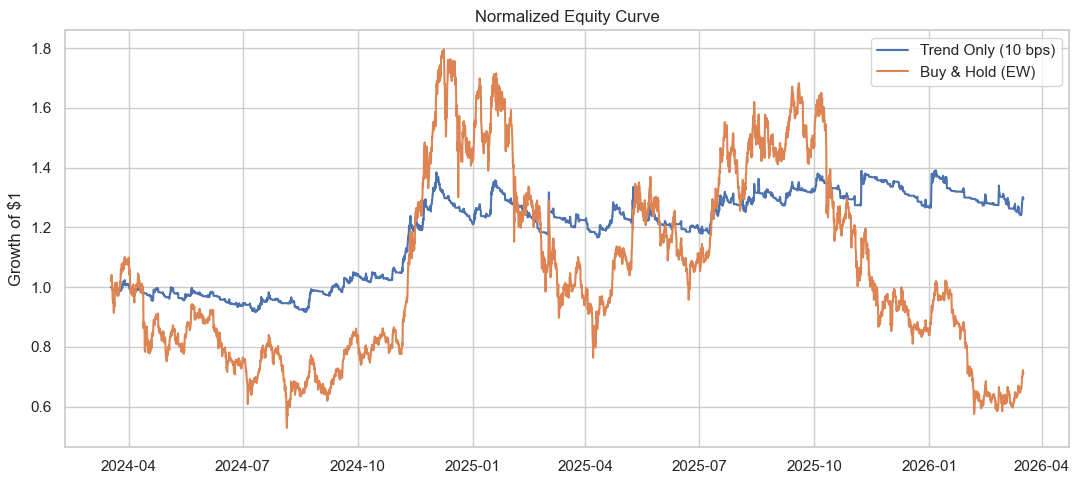

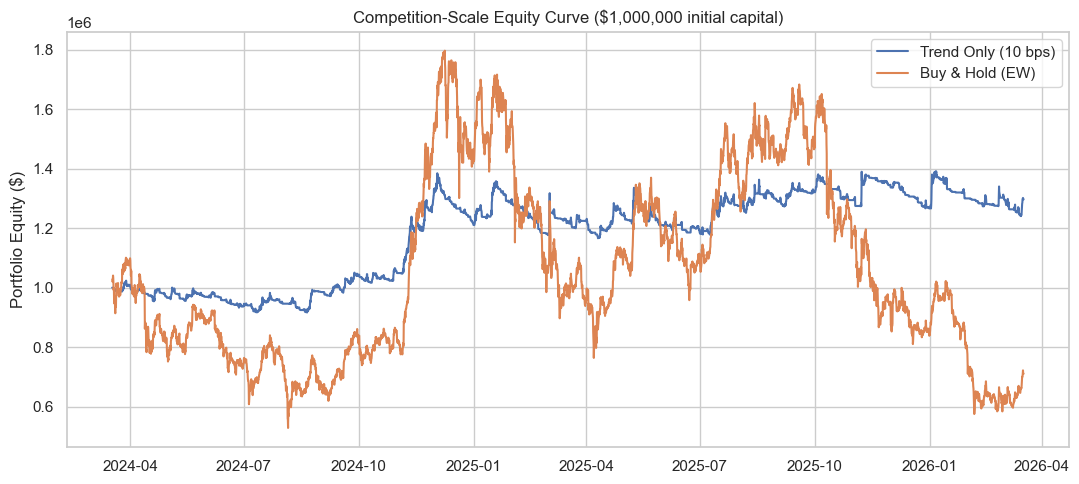

In [34]:
plt.figure(figsize=(11, 5))
plt.plot(results[10].index, results[10]["wealth"], label="Trend Only (10 bps)")
plt.plot(benchmark.index, benchmark["wealth"], label="Buy & Hold (EW)")
plt.title("Normalized Equity Curve")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(results[10].index, results[10]["equity"], label="Trend Only (10 bps)")
plt.plot(benchmark.index, benchmark["equity"], label="Buy & Hold (EW)")
plt.title("Competition-Scale Equity Curve ($1,000,000 initial capital)")
plt.ylabel("Portfolio Equity ($)")
plt.legend()
plt.tight_layout()
plt.show()


## 11) Selected Configuration

In [35]:
selected_summary = pd.DataFrame({
    "breakout_lookback": [best_cfg["breakout_lookback"]],
    "exit_lookback": [best_cfg["exit_lookback"]],
    "max_hold_bars": [best_cfg["max_hold_bars"]],
    "trailing_stop_pct": [best_cfg["trailing_stop_pct"]],
    "tranche_scheme": [best_cfg["tranche_scheme"]],
    "use_btc_filter": [best_cfg["use_btc_filter"]],
    "risk_per_trade": [RISK_PER_TRADE],
    "max_open_positions": [MAX_OPEN_POSITIONS],
})
selected_summary


,breakout_lookback,exit_lookback,max_hold_bars,trailing_stop_pct,tranche_scheme,use_btc_filter,risk_per_trade,max_open_positions
0,6,6,9,0.06,"(0.35, 0.35, 0.3)",False,0.015,5


### Deployment Assessment

From a deployment perspective, the preferred specification is one that combines positive post-cost performance, bounded drawdown, moderate turnover, and simple deterministic rules. The live trading requirement is not just statistical quality but operational clarity: the strategy should map directly into a bar-close decision process, produce auditable actions, and avoid unnecessary implementation complexity.

## Research Conclusion

This notebook should be interpreted as a deployment-focused research report rather than a pure optimization exercise. The selected strategy is credible if it demonstrates three properties simultaneously: positive or at least resilient out-of-sample performance after costs, materially better drawdown control than passive exposure, and a rule set that can be implemented cleanly in a live automated system.

If those conditions hold, the strategy is suitable to advance from research into controlled live testing. If they do not, the correct conclusion is not to add more complexity immediately, but to revisit the economic logic of the signal and its holding / exit structure before deployment.